In [1]:
import os
import numpy as np
import torch
import sklearn
from matplotlib import pyplot as plt
from clustpy.deep import DEC, IDEC, DCN, DDC, DipEncoder, DipDECK
from clustpy.deep.autoencoders import FeedforwardAutoencoder
from ddc import DDC as SHADE
device = 'cuda:0'
os.environ['CLUSTPY_DEVICE'] = device

In [2]:
from clustpy.deep._utils import set_torch_seed
set_torch_seed(np.random.RandomState(1))

In [134]:
from sklearn.preprocessing import scale
dim = 2
X = scale(np.random.uniform(0,1, size=(2500, dim)))

# X = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
# X = np.column_stack((X[0].flatten(), X[1].flatten()))

X_tensor = torch.from_numpy(X).float().to(device)

In [135]:
batch_size = 256
# layers = [dim,10,10,2]
layers = [dim, 512, 256, 128, 2]
ae = FeedforwardAutoencoder(layers=layers).to(device)
ae.fit(data=X, n_epochs=200, optimizer_params={"lr":1e-3}, print_step=50, batch_size=batch_size, device=device)
emb = ae.encode(X_tensor).detach().cpu().numpy()

Epoch 1/199 - Batch Reconstruction loss: 0.044757
Epoch 51/199 - Batch Reconstruction loss: 0.000030
Epoch 101/199 - Batch Reconstruction loss: 0.000102
Epoch 151/199 - Batch Reconstruction loss: 0.000007
Epoch 199/199 - Batch Reconstruction loss: 0.000488


In [146]:
from sklearn.manifold import TSNE
from clustpy.deep import encode_batchwise

tsne_params = {"random_state": 1, "n_components": 2}
clusterer = DDC(
    embedding_size=10, autoencoder=ae, tsne_params=tsne_params, random_state=1
).fit(X)
embedded = clusterer.autoencoder.encode(torch.tensor(X, device=device).float())
tsne = TSNE(**tsne_params)
embedded_ddc = tsne.fit_transform(embedded.cpu().detach().numpy())

In [185]:
len(embs)
names = np.array(["AE", "SHADE", "DipDeck", "DDC", "DipEncoder", "DCN", "DEC", "IDEC"])
eell = np.array([embs[5], embs[0], embs[6], embs[4], embs[7], embs[3], embs[1], embs[2]])

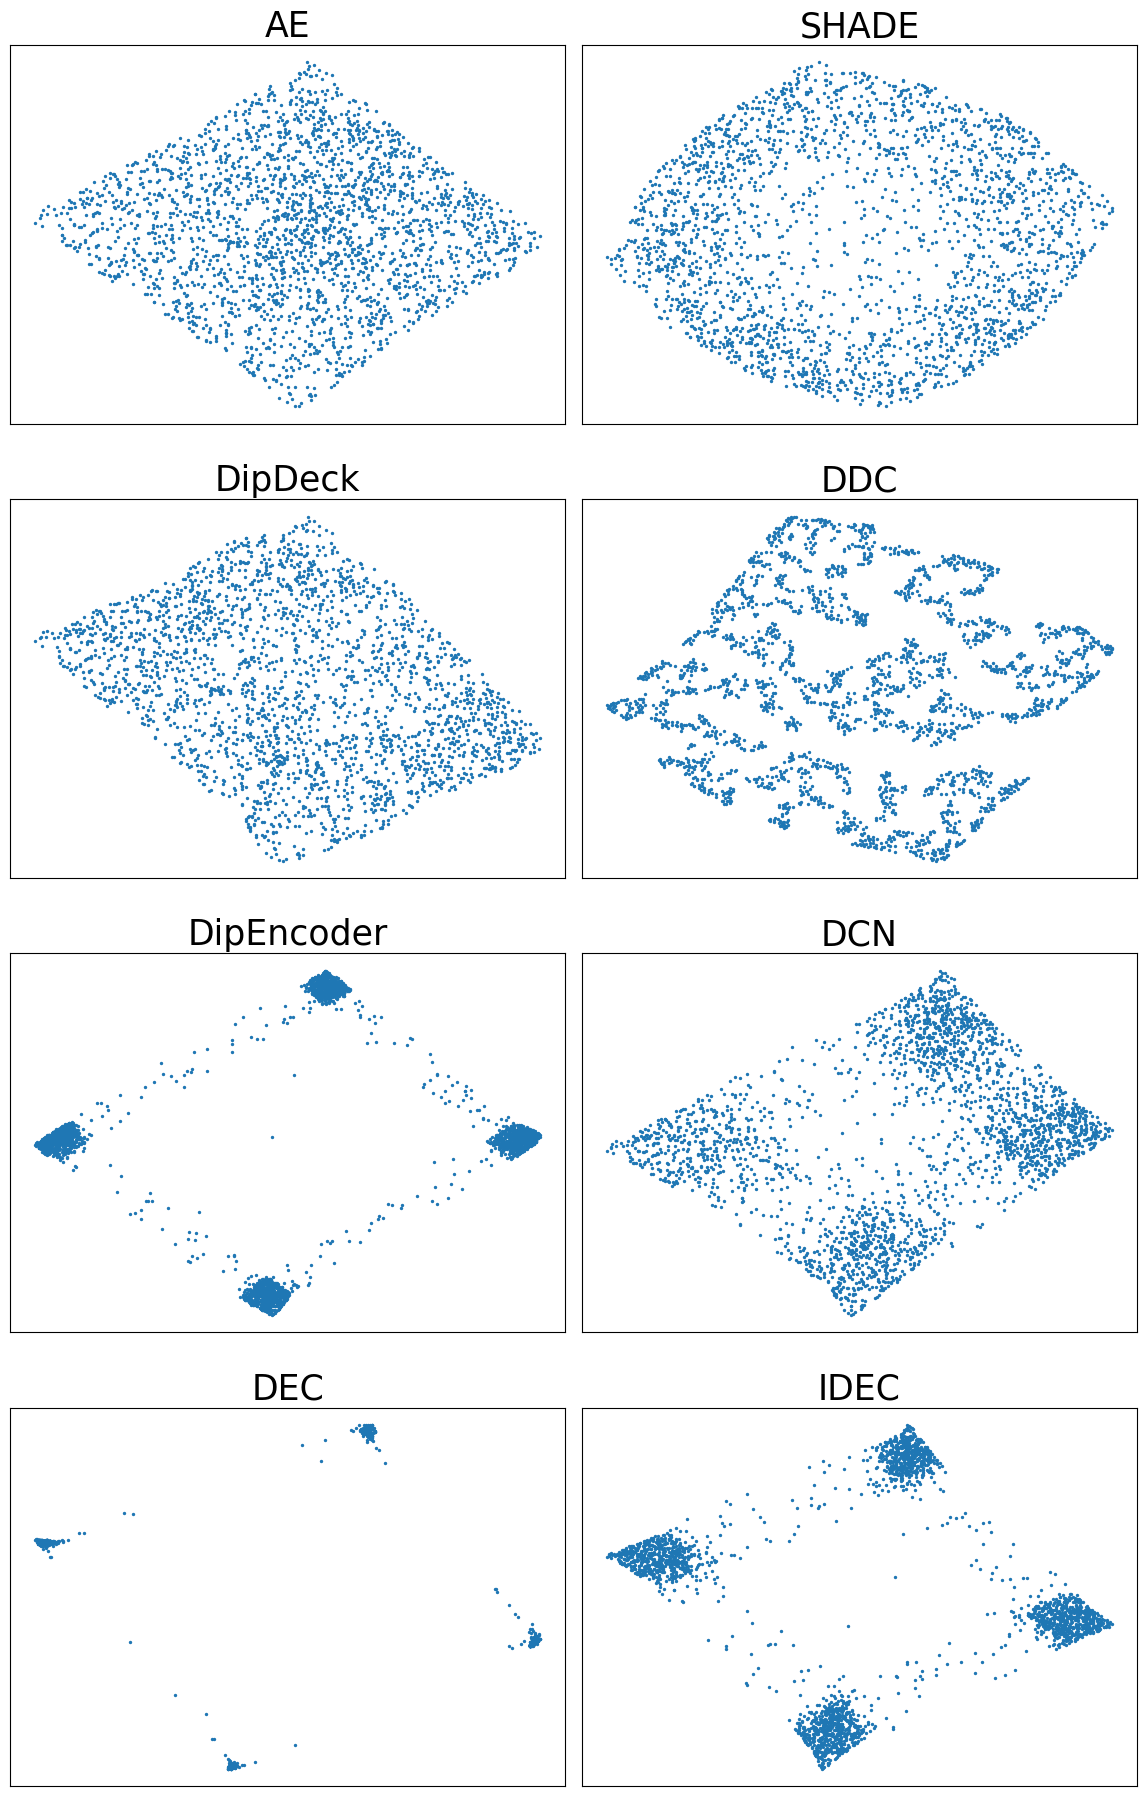

In [204]:
fig, axes = plt.subplots(figsize=(12, 18), ncols=2, nrows=4)
fig.tight_layout()

for i in range(8):
    ax = axes[i//2, i%2]
    ax.scatter(eell[i][:, 0], eell[i][:, 1], s=2) #, c=cluster_labels)
    ax.set_title(names[i])

    ax.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )  # labels along the bottom edge are off
    ax.tick_params(
        axis="y",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        left=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelleft=False,
    )  # labels along the bottom edge are off
    for item in (
        [ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    ):
        item.set_fontsize(25)
fig.subplots_adjust(hspace=0.2)
fig.subplots_adjust(wspace=0.03)

DDC
Use non-trained autoencoder
Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.


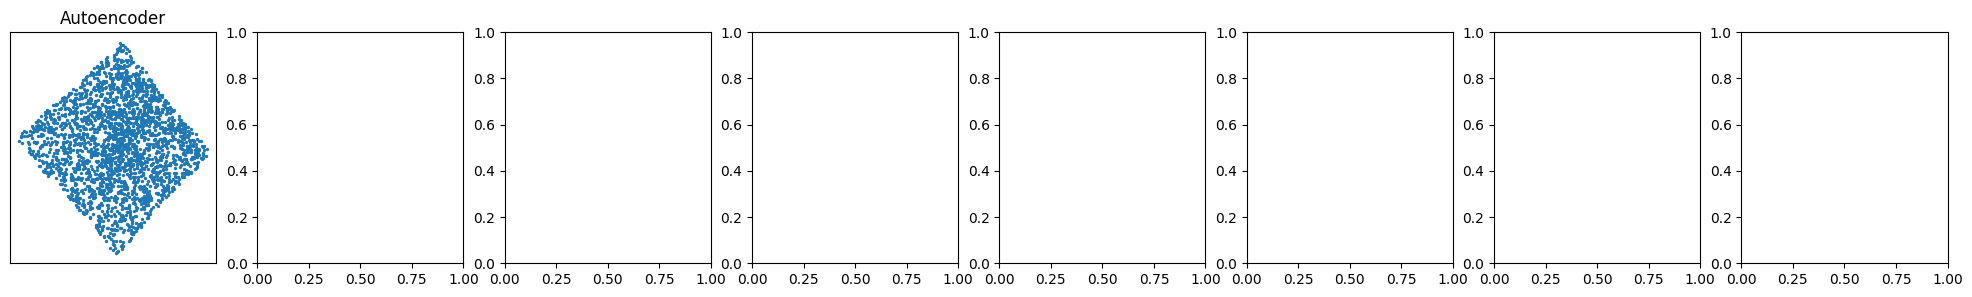

DEC


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


IDEC


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


DCN


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


DipEncoder


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


DipDECK


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [148]:
n_clusters = 4

fig, axes = plt.subplots(figsize=(25, 3), ncols=8, nrows=1)
ax = axes[0]
ax.set_title("Autoencoder")
ax.scatter(emb[:, 0], emb[:, 1], s=2)
ax.tick_params(
    axis="x",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    bottom=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelbottom=False,
)  # labels along the bottom edge are off
ax.tick_params(
    axis="y",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    left=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelleft=False,
)  # labels along the bottom edge are off


embs = []

for col_idx, dc_method_class in enumerate([SHADE, DEC, IDEC, DCN], 1):
    print(dc_method_class.__name__)
    autoenc = ae
    if dc_method_class == SHADE:
        print("Use non-trained autoencoder")
        autoenc = FeedforwardAutoencoder(layers=layers).to(device)
    dc_method = dc_method_class(
        n_clusters=n_clusters,
        clustering_epochs=100,
        clustering_optimizer_params={"lr": 5e-4},
        autoencoder=autoenc,
        batch_size=batch_size,
        embedding_size=2,
    )
    if dc_method_class == SHADE:
        dc_method.min_points = 5
        dc_method.standardize=False

    dc_method.fit(X=X)
    cluster_labels = dc_method.labels_
    emb_i = dc_method.autoencoder.encode(X_tensor).detach().cpu().numpy()
    embs.append(emb_i)
    centers = dc_method.cluster_centers_
    ax = axes[col_idx]
    ax.scatter(emb_i[:, 0], emb_i[:, 1], s=2) #, c=cluster_labels)
    # ax.scatter(centers[:, 0], centers[:, 1], s=100, marker="P", color="black")
    ax.set_title(dc_method_class.__name__)

    if dc_method_class == SHADE:
        ax.set_title("SHADE")
    else:
        ax.set_title(dc_method_class.__name__)

    ax.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )  # labels along the bottom edge are off
    ax.tick_params(
        axis="y",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        left=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelleft=False,
    )  # labels along the bottom edge are off


In [157]:

for col_idx, dc_method_class in enumerate([DipEncoder], 5):
    print(dc_method_class.__name__)
    autoenc = ae
    if dc_method_class == SHADE:
        print("Use non-trained autoencoder")
        autoenc = FeedforwardAutoencoder(layers=layers).to(device)
    dc_method = dc_method_class(
        n_clusters=n_clusters,
        clustering_epochs=100,
        clustering_optimizer_params={"lr": 5e-4},
        autoencoder=autoenc,
        batch_size=batch_size,
        embedding_size=2,
    )
    dc_method.fit(X=X)
    cluster_labels = dc_method.labels_
    emb_i = dc_method.autoencoder.encode(X_tensor).detach().cpu().numpy()
    embs.append(emb_i)
    ax = axes[col_idx]
    ax.scatter(emb_i[:, 0], emb_i[:, 1], s=2) #, c=cluster_labels)
    ax.set_title(dc_method_class.__name__)

    ax.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )  # labels along the bottom edge are off
    ax.tick_params(
        axis="y",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        left=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelleft=False,
    )  # labels along the bottom edge are off



DipEncoder


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [156]:

for col_idx, dc_method_class in enumerate([DipDECK], 6):
    print(dc_method_class.__name__)
    autoenc = ae
    if dc_method_class == SHADE:
        print("Use non-trained autoencoder")
        autoenc = FeedforwardAutoencoder(layers=layers).to(device)
    dc_method = dc_method_class(
        clustering_epochs=100,
        clustering_optimizer_params={"lr": 5e-4},
        autoencoder=autoenc,
        batch_size=batch_size,
        embedding_size=2,
    )
    dc_method.fit(X=X)
    cluster_labels = dc_method.labels_
    emb_i = dc_method.autoencoder.encode(X_tensor).detach().cpu().numpy()
    embs.append(emb_i)
    centers = dc_method.cluster_centers_
    ax = axes[col_idx]
    ax.scatter(emb_i[:, 0], emb_i[:, 1], s=2) #, c=cluster_labels)
    # ax.scatter(centers[:, 0], centers[:, 1], s=100, marker="P", color="black")
    ax.set_title(dc_method_class.__name__)

    ax.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )  # labels along the bottom edge are off
    ax.tick_params(
        axis="y",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        left=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelleft=False,
    )  # labels along the bottom edge are off

# ax.legend(markerscale=5)
plt.show()

DipDECK


/export/home/pascalw777dm/pascalw777dm/miniconda3/envs/stuff/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


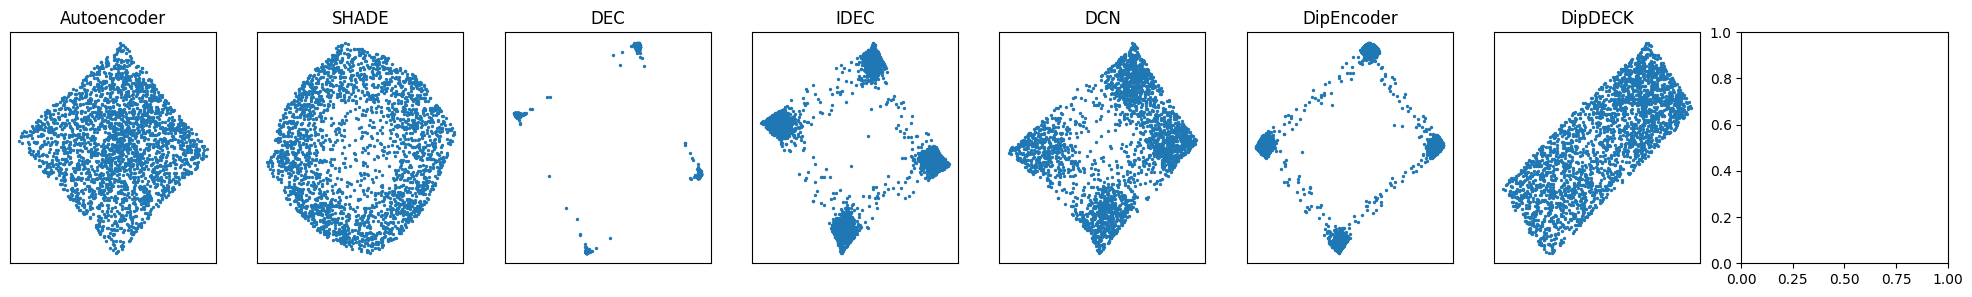

In [149]:
fig

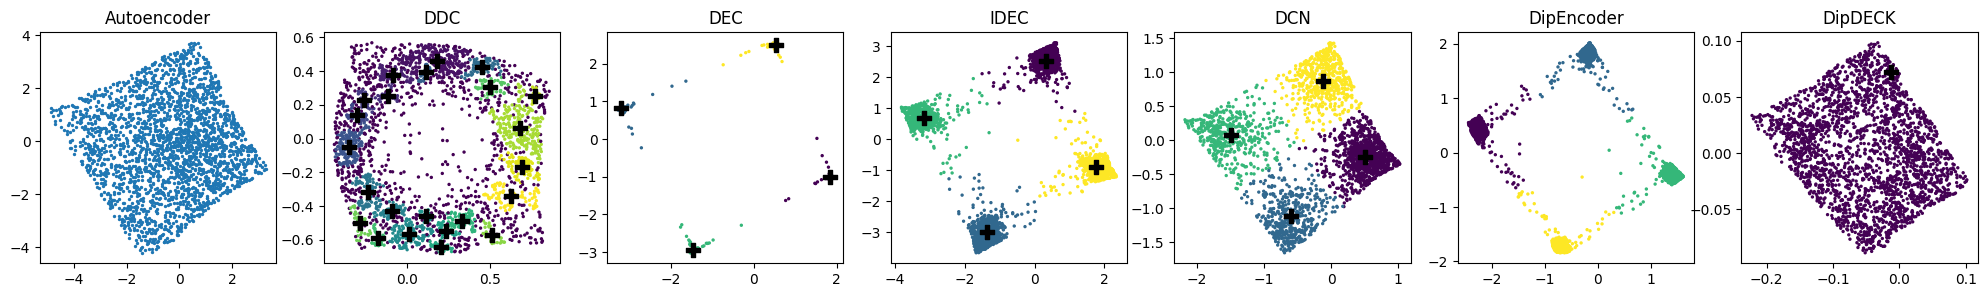

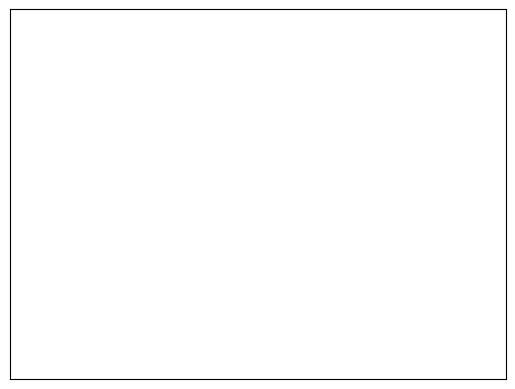

In [71]:
plt.tick_params(
    axis="x",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    bottom=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelbottom=False,
)  # labels along the bottom edge are off
plt.tick_params(
    axis="y",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    left=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelleft=False,
)  # labels along the bottom edge are off
fig

In [106]:
autoenc = FeedforwardAutoencoder(layers=layers).to(device)

In [122]:
shade = SHADE(
    min_points=5,
    clustering_epochs=100,
    clustering_optimizer_params={"lr": 5e-4},
    autoencoder=autoenc,
    batch_size=batch_size,
    embedding_size=2,
    standardize=False
)

In [123]:
shade.fit(X)

Start training with clustering loss.


DDC(autoencoder=FeedforwardAutoencoder(
  (encoder): FullyConnectedBlock(
    (block): Sequential(
      (0): Linear(in_features=2, out_features=512, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=512, out_features=256, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): LeakyReLU(negative_slope=0.01)...
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=256, out_features=512, bias=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Linear(in_features=512, out_features=2, bias=True)
    )
  )
),
    batch_size=256, clustering_optimizer_params={'lr': 0.0005},
    device=device(type='cuda', index=0), embedding_size=2, min_points=30,
    n_clusters=23, random_state=RandomState(MT19937) at 0x7F02840E1940,
    standardize=False)

In [124]:
emb_i = shade.encode(X)

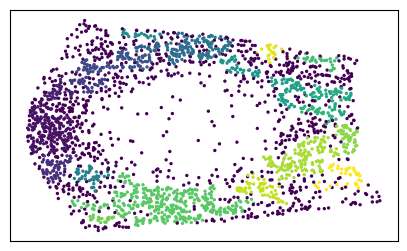

In [125]:
l_ = shade.labels_
fig2, ax2 = plt.subplots(figsize=(5, 3), ncols=1)
ax2.scatter(emb_i[:, 0], emb_i[:, 1], s=2, c=l_)
plt.tick_params(
    axis="x",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    bottom=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelbottom=False,
)  # labels along the bottom edge are off
plt.tick_params(
    axis="y",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    left=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelleft=False,
)  # labels along the bottom edge are off

In [120]:
from dcdist.dctree_clusterer import DCTree_Clusterer


clus = DCTree_Clusterer(30)
l__ = clus.fit_predict(emb_i)

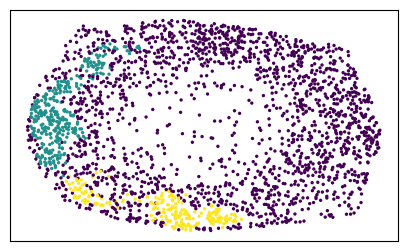

In [121]:
l_ = shade.labels_
fig2, ax2 = plt.subplots(figsize=(5, 3), ncols=1)
ax2.scatter(emb_i[:, 0], emb_i[:, 1], s=2, c=l__)
plt.tick_params(
    axis="x",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    bottom=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelbottom=False,
)  # labels along the bottom edge are off
plt.tick_params(
    axis="y",  # changes apply to the x-axis
    which="both",  # both major and minor ticks are affected
    left=False,  # ticks along the bottom edge are off
    top=False,  # ticks along the top edge are off
    labelleft=False,
)  # labels along the bottom edge are off